# Linear Regression


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [2]:
df = pd.read_csv('height-weight.csv')
df

,Weight,Height
0,45,120
1,58,135
2,48,123
3,60,145
4,70,160
5,78,162
6,80,163
7,90,175
8,95,182
9,78,170


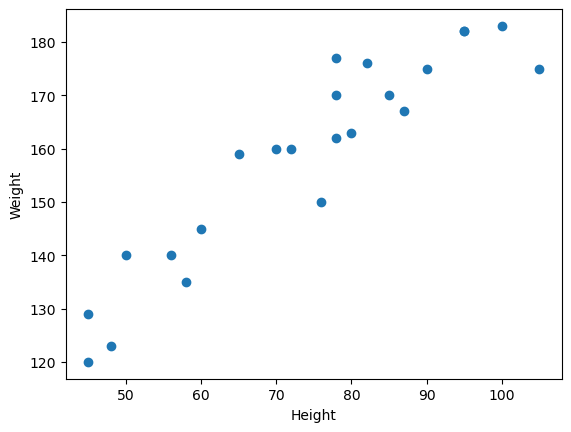

In [4]:
plt.scatter( df['Weight'],df['Height'])
plt.xlabel('Height')
plt.ylabel('Weight')
plt.show()

In [5]:
df.corr()
# Highly corelated as the correlation is 0.93

,Weight,Height
Weight,1.000000,0.931142
Height,0.931142,1.000000


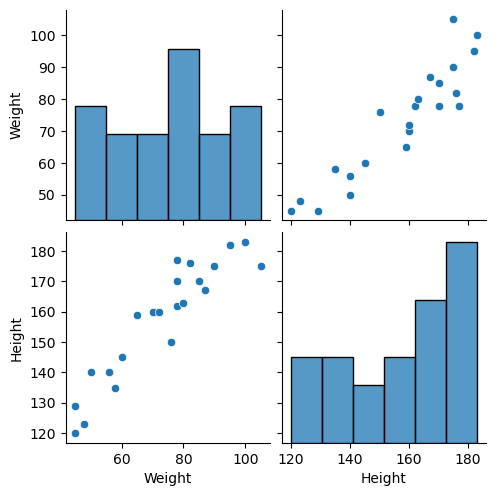

In [6]:
sns.pairplot(df)

In [7]:
# Dividing features is dependent and independent feature...
# Independent
X = df[['Weight']] # type must me dataframe or 2-D array.
# Dependent 
y = df['Height']

In [8]:
# Train Test  Split
from sklearn.model_selection import train_test_split

In [9]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

In [10]:
X_train.shape

(17, 1)

In [11]:
# Standardization
from sklearn.preprocessing import StandardScaler

In [13]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)

In [14]:
X_test = scaler.transform(X_test)

In [15]:
## Plly linear Regression
from sklearn.linear_model import LinearRegression

In [19]:
regression = LinearRegression(n_jobs=-1)

In [20]:
regression.fit(X_train, y_train)

LinearRegression(n_jobs=-1)

In [23]:
print(f"Coefficient or Slope:", regression.coef_) # Slope
print(f"Intercept:", regression.intercept_) # y-intercept

Coefficient or Slope: [17.2982057]
Intercept: 156.47058823529412


### This coefficient says that one unit change in the weight feature will be 17.29 unit change in the height feature

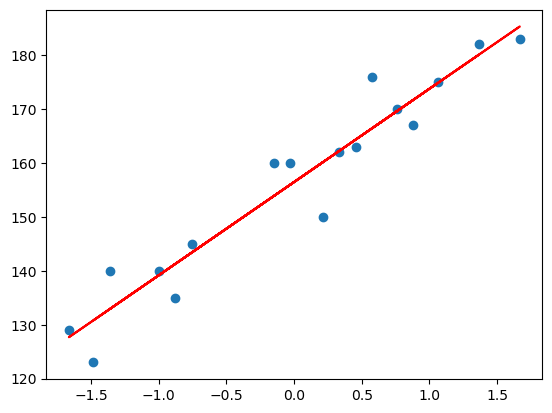

In [25]:
# plot the best fit line
plt.scatter(X_train, y_train)
plt.plot(X_train, regression.predict(X_train), color="r")

In [26]:
# Prediction for test data
y_pred = regression.predict(X_test)

## Performance Matrix


In [27]:
from sklearn.metrics import mean_squared_error, mean_absolute_error

In [29]:
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mse)

print(f"Mean Squared Error: {mse}")
print(f"Mean Absolute Error: {mae}")
print(f"Root Mean Squared Error: {rmse}")


Mean Squared Error: 114.84069295228699
Mean Absolute Error: 9.665125886795005
Root Mean Squared Error: 10.716374991212605


In [30]:
from sklearn.metrics import r2_score
r2 = r2_score(y_test, y_pred)
print(f"R^2 Score: {r2}")

R^2 Score: 0.7360826717981276


In [34]:
# Adjusted R^2 Score
adj_r2 = 1 - (1-r2)*(len(y_test)-1)/(len(y_test)-X_test.shape[1]-1)
print(f"Adjusted R^2 Score: {adj_r2}")

Adjusted R^2 Score: 0.6701033397476595


# Now we try the OLS(Ordinary Least Square) technique

In [36]:
import statsmodels.api as sm

In [37]:
model = sm.OLS(y_train, X_train).fit()

In [39]:
prediction = model.predict(X_test)
print("Prediction: ", prediction)


Prediction:  [  5.79440897   5.79440897 -28.78711691  23.60913442  -7.82861638
  34.08838469]


In [40]:
print(model.summary())

                                 OLS Regression Results                                
Dep. Variable:                 Height   R-squared (uncentered):                   0.012
Model:                            OLS   Adj. R-squared (uncentered):             -0.050
Method:                 Least Squares   F-statistic:                             0.1953
Date:                Sat, 05 Jul 2025   Prob (F-statistic):                       0.664
Time:                        23:40:25   Log-Likelihood:                         -110.03
No. Observations:                  17   AIC:                                      222.1
Df Residuals:                      16   BIC:                                      222.9
Df Model:                           1                                                  
Covariance Type:            nonrobust                                                  
                 coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------

c:\Users\OM MAKWANA\anaconda3\Lib\site-packages\scipy\stats\_axis_nan_policy.py:531: UserWarning: kurtosistest only valid for n>=20 ... continuing anyway, n=17
  res = hypotest_fun_out(*samples, **kwds)


# Prediction For NEW DATA

In [41]:
regression.predict([[72]])

array([1401.94139895])

- here, why are we getting the height as 1401....?
- this is bcoz we didnt standardized the data...

In [43]:
regression.predict(scaler.transform([[72]]))

c:\Users\OM MAKWANA\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


array([155.97744705])